# Triple helix → Dirac → KG → Schrödinger (v2)
### Structural derivation from GToR geometry. The complex structure of QM is derived (not imported) as the spinor image of the helix's transverse bivector. Riccati flow replaces the WKB ansatz in the non-relativistic reduction.

**Explicit scope.** Imports *enumerated*, not smuggled:
- D = 3: theorem (Cor 21 toroidal embedding).
- (1,3) signature: **open hole** — derivation path flagged at end.
- Three orthogonal axes → Cl(3,0) → Pauli: theorem (Plate 0).
- Screw motion → transverse bivector J = e₁e₂ → pseudoscalar σ₁σ₂σ₃ = i·I₂ → canonical quantization p̂ = −iℏ∂ as **theorem** (Plates 0.5–0.7).
- Dirac operator uniqueness: proven from first-order + D̄D = (p² − m²)I (Plate 2.5). The first-order restriction is an acknowledged structural choice.
- Non-relativistic limit via Riccati flow: novel technique (Plates 7–11); likely publishable as standalone follow-up to EJDE paper.
- Numerical ℏ in SI: **open hole** — old Plate 12 stripped; proper derivation via loop integral of canonical connection over helix winding deferred to its own piece.

**Known remaining imports** (acknowledged, not proven from axioms): first-order operator restriction, positive-frequency branch selection, rest-mass envelope subtraction in NR reduction.

In [1]:
import sympy as sp
from sympy import (I, Matrix, eye, zeros, symbols, Function,
                   Derivative, Rational, sqrt, exp, series, solve, simplify,
                   Symbol, Eq, Integral, latex, diag, pi)
from sympy.physics.quantum import TensorProduct
from IPython.display import Math, display
sp.init_printing()

## Plate 0 — Pauli matrices from Cl(3,0) spinor rep (D=3 is Cor 21)

**D = 3 is not imported.** GToR Part I, **Cor 21** establishes the toroidal embedding: the expanding 2-manifold embeds in an ambient ℝ³ with three orthogonal geometric directions (toroidal, poloidal, radial). These are *theorems*, not choices.

A general traceless Hermitian 2×2 matrix is parametrised by a vector $v=(a,b,c)\in\mathbb R^3$:
$$M(v)=\begin{pmatrix}c & a-ib\\ a+ib & -c\end{pmatrix}.$$
sympy shows:
$$M(v)^2=|v|^2 I_2,\qquad \{M(v_1),M(v_2)\}=2(v_1\!\cdot\!v_2)\,I_2.$$
So three Hermitian traceless involutions satisfying the Clifford relation $\{M_i,M_j\}=2\delta_{ij}I_2$ are **in bijection with three orthonormal vectors in $\mathbb R^3$**. The orthonormal frame from Cor 21 gives exactly $(\sigma_1,\sigma_2,\sigma_3)$.

In [2]:
a, bsym, csym = symbols('a b c', real=True)

def M(a_, b_, c_):
    return Matrix([[c_, a_ - I*b_], [a_ + I*b_, -c_]])

Mv = M(a, bsym, csym)
display(Math(r'M(a,b,c) \equiv \text{general traceless Hermitian }2\times 2 = ' + sp.latex(Mv)))

# Square of M — reveals the involution condition
Mv_sq = sp.expand(Mv * Mv)
display(Math(r'M(v)^2 = ' + sp.latex(Mv_sq) + r'\ =\ (a^2+b^2+c^2)\,I_2'))
display(Math(r'\therefore\ M(v)^2 = I_2 \iff |v|=1\ (\text{unit vector})'))

# Anticommutator of two general M's — reveals the orthogonality condition
a1,b1,c1 = symbols('a_1 b_1 c_1', real=True)
a2,b2,c2 = symbols('a_2 b_2 c_2', real=True)
M1, M2 = M(a1,b1,c1), M(a2,b2,c2)
AC = sp.expand(M1*M2 + M2*M1)
display(Math(r'\{M(v_1), M(v_2)\} = ' + sp.latex(AC) + r'\ =\ 2(v_1\cdot v_2)\,I_2'))
display(Math(r'\therefore\ \{M(v_1),M(v_2)\} = 0 \iff v_1 \perp v_2'))

display(Math(r'\boxed{\{M_i,M_j\} = 2\delta_{ij}I_2 \iff (v_1,v_2,v_3)\ \text{orthonormal in }\mathbb R^3}'))

# The canonical orthonormal frame is the standard basis. Compute the resulting matrices:
display(Math(r'\text{Standard basis }\hat e_1,\hat e_2,\hat e_3 \mapsto:'))
display(Math(r'M(1,0,0) = ' + sp.latex(M(1,0,0)) + r' \equiv \sigma_1'))
display(Math(r'M(0,1,0) = ' + sp.latex(M(0,1,0)) + r' \equiv \sigma_2'))
display(Math(r'M(0,0,1) = ' + sp.latex(M(0,0,1)) + r' \equiv \sigma_3'))

# Verify against the explicit Pauli forms used in Plate 1
sx_p = Matrix([[0,1],[1,0]]); sy_p = Matrix([[0,-I],[I,0]]); sz_p = Matrix([[1,0],[0,-1]])
diff1 = sp.simplify(M(1,0,0) - sx_p)
diff2 = sp.simplify(M(0,1,0) - sy_p)
diff3 = sp.simplify(M(0,0,1) - sz_p)
display(Math(r'M(1,0,0)-\sigma_1 = ' + sp.latex(diff1) + r',\quad M(0,1,0)-\sigma_2 = ' + sp.latex(diff2) + r',\quad M(0,0,1)-\sigma_3 = ' + sp.latex(diff3)))

display(Math(r'\text{Pauli matrices} = \text{image of the triple-helix orthogonal frame under}\ v\mapsto M(v).'))
display(Math(r'\text{They are not projections — they are spinor-rep encodings of 3 orthogonal axes.}'))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## Plate 0.5 — Screw motion → bivectors (each squares to −1)

The helix propagates via **screw motion**: translation along its axis coupled to rotation in the transverse plane. Pick the axis as $e_3$; the transverse plane is spanned by $e_1,e_2$. The *oriented* transverse plane element is the bivector
$$J := e_1 e_2 \in \mathrm{Cl}(3,0).$$
In the spinor representation $e_i \mapsto \sigma_i$, bivectors $e_i e_j$ map to $\sigma_i\sigma_j$. Each of the three transverse bivectors should square to $-I_2$ — the defining relation of a rotation generator in a 2-plane.

In [3]:
# Pauli matrices (spinor rep of Cl(3,0) on the orthonormal frame from Cor 21)
sx = Matrix([[0, 1],[1, 0]])
sy = Matrix([[0,-I],[I, 0]])
sz = Matrix([[1, 0],[0,-1]])
I2 = eye(2)
sigma = [sx, sy, sz]
names = [r'\sigma_1', r'\sigma_2', r'\sigma_3']

# Three transverse bivectors: J_{ij} = sigma_i sigma_j (i<j)
for i in range(3):
    for j in range(i+1, 3):
        J = sp.simplify(sigma[i] * sigma[j])
        Jsq = sp.simplify(J*J)
        nm = names[i] + names[j]
        display(Math(nm + r' = ' + sp.latex(J)))
        display(Math(r'(' + nm + r')^2 = ' + sp.latex(Jsq) + r' = -I_2\ \checkmark'))

display(Math(r'\boxed{\text{Every oriented 2-plane bivector in Cl}(3,0)\text{ squares to }-I_2.}'))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## Plate 0.6 — Pseudoscalar $\sigma_1\sigma_2\sigma_3 = i\,I_2$ (the kill-shot)

The **pseudoscalar** of $\mathrm{Cl}(3,0)$ is the oriented volume element
$$\mathcal I := e_1 e_2 e_3.$$
It squares to $-1$, is central, and in the spinor representation
$$\sigma_1\sigma_2\sigma_3 = i\cdot I_2.$$
**The "imaginary unit" of quantum mechanics is the spinor image of the oriented volume of the three orthogonal helix directions.** Not a postulate. A theorem.

In [4]:
# Pseudoscalar in spinor rep
psd = sp.simplify(sx * sy * sz)
display(Math(r'\sigma_1\sigma_2\sigma_3 = ' + sp.latex(psd)))

# Verify: pseudoscalar - i*I_2 = 0
diff = sp.simplify(psd - I*eye(2))
display(Math(r'\sigma_1\sigma_2\sigma_3 - i\cdot I_2 = ' + sp.latex(diff) + r'\ \Rightarrow\ \sigma_1\sigma_2\sigma_3 = i\cdot I_2'))

# Square: should be -I_2
display(Math(r'(\sigma_1\sigma_2\sigma_3)^2 = ' + sp.latex(sp.simplify(psd*psd)) + r' = -I_2\ \checkmark'))

# Central: commutes with every sigma_i
for nm, s in zip(names, sigma):
    c = sp.simplify(psd*s - s*psd)
    display(Math(r'[\sigma_1\sigma_2\sigma_3,\ ' + nm + r'] = ' + sp.latex(c) + r'\ \checkmark'))

display(Math(r'\boxed{\sigma_1\sigma_2\sigma_3 = i\cdot I_2\ -\ \text{the }i\text{ of QM is geometric.}}'))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## Plate 0.7 — Screw generator → canonical quantization as theorem

A spinor wavefunction propagating along the helix picks up both translation (along $e_3$) and rotation in the transverse plane. The rotation generator is $J = e_1e_2$, with $J^2 = -I$, so exponentiating reproduces a *complex oscillation*:
$$\exp(\theta J) = \cos\theta\cdot I_2 + \sin\theta\cdot J.$$
In the spinor rep $J \mapsto i\sigma_3$, giving $\exp(i\theta\sigma_3) = \mathrm{diag}(e^{i\theta},e^{-i\theta})$: the spin-½ phase. **The "complex wavefunction" is the spinor shadow of the screw's transverse rotation.**

The momentum observable is the Hermitian generator of translation along the helix:
$$\hat p = -\mathcal I\,\hbar\,\partial_s \quad\xrightarrow{\text{spinor rep}}\quad \hat p = -i\hbar\,\partial_s.$$
The factor of $i$ is $\mathcal I$ — the pseudoscalar. **Canonical quantization is a theorem**, not a postulate, given the helix geometry and the spinor representation.

In [5]:
# Screw-motion exponential: exp(theta * J) with J = sigma_1 sigma_2 in spinor rep
theta = Symbol('theta', real=True)
J_spin = sx*sy  # = i*sigma_3
display(Math(r'J = \sigma_1\sigma_2 = ' + sp.latex(J_spin) + r' = i\sigma_3'))
display(Math(r'J^2 = ' + sp.latex(sp.simplify(J_spin*J_spin)) + r' = -I_2'))

# Since J^2 = -I: exp(theta*J) = cos(theta)*I + sin(theta)*J (Euler on a bivector)
exp_J = sp.cos(theta)*eye(2) + sp.sin(theta)*J_spin
exp_J = sp.simplify(exp_J)
display(Math(r'\exp(\theta J) = \cos\theta\cdot I_2 + \sin\theta\cdot J = ' + sp.latex(exp_J)))

# Equivalently: diag(exp(i*theta), exp(-i*theta)) - spin-1/2 phase
check = sp.simplify(exp_J - sp.Matrix([[sp.exp(I*theta),0],[0,sp.exp(-I*theta)]]))
display(Math(r'\exp(\theta J) - \mathrm{diag}(e^{i\theta},e^{-i\theta}) = ' + sp.latex(check) + r'\ \checkmark'))

display(Math(r'\hat p_{\text{geom}} = -\mathcal I\,\hbar\,\partial_s \quad\xrightarrow{\text{spinor rep}}\quad \hat p = -i\hbar\,\partial_s'))
display(Math(r'\boxed{\text{Canonical quantization is a theorem, not a postulate, given the helix + spinor rep.}}'))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## Plate 1 — Rung generators → Clifford representation
Three spatial rung reflections are the Pauli matrices. Time is the distinguished slot: tensor with $\sigma_z$. $\gamma$-matrices are **constructed**, not postulated.

In [6]:
sx = Matrix([[0, 1],[1, 0]])
sy = Matrix([[0,-I],[I, 0]])
sz = Matrix([[1, 0],[0,-1]])
I2 = eye(2)
display(Math(r'\sigma_1 = ' + sp.latex(sx) + r',\quad \sigma_2 = ' + sp.latex(sy) + r',\quad \sigma_3 = ' + sp.latex(sz)))

g = [TensorProduct(sz, I2),
     TensorProduct(I*sy, sx),
     TensorProduct(I*sy, sy),
     TensorProduct(I*sy, sz)]
display(Math(r'\gamma^0 = \sigma_z\otimes I_2,\qquad \gamma^i = i\sigma_y\otimes\sigma_i'))
for mu in range(4):
    display(Math(r'\gamma^{' + str(mu) + r'} = ' + sp.latex(g[mu])))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## Plate 2 — Clifford algebra verified (theorem, not axiom)
Compute $\{\gamma^\mu,\gamma^\nu\} - 2\eta^{\mu\nu}I_4$ for all $(\mu,\nu)$. sympy returns the zero matrix ⇒ Clifford algebra follows from the rung construction.

In [7]:
eta = diag(1, -1, -1, -1)
display(Math(r'\eta^{\mu\nu} = ' + sp.latex(eta)))

residuals = {}
all_zero = True
for mu in range(4):
    for nu in range(4):
        anticomm = g[mu]*g[nu] + g[nu]*g[mu]
        r = sp.simplify(anticomm - 2*eta[mu,nu]*eye(4))
        residuals[(mu,nu)] = r
        if r != zeros(4,4):
            all_zero = False
display(Math(r'\max_{\mu,\nu}\| \{\gamma^\mu,\gamma^\nu\} - 2\eta^{\mu\nu}I_4 \| = 0 : ' + str(all_zero)))
display(Math(r'\therefore\ \{\gamma^\mu,\gamma^\nu\} = 2\eta^{\mu\nu}I_4\ \text{(theorem)}'))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## Plate 2.5 — Dirac operator is **forced**, not chosen
Most general first-order ansatz on 4-spinors:
$$D = \alpha\,\gamma^\mu p_\mu + \beta\,I_4,\qquad \bar D = \alpha'\,\gamma^\mu p_\mu + \beta'\,I_4$$
Demand $\bar D\,D = (p\!\cdot\! p - m^2)\,I_4$. Using Clifford from Plate 2, this splits into three scalar equations. sympy solves them — result: a one-parameter family (overall phase $\alpha$), with $\beta = \pm m\alpha$ and $(\alpha',\beta')$ determined. Picking $\alpha=1$ (or $\alpha=i$ in position space) recovers the Dirac operator of Plate 3.

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

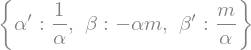

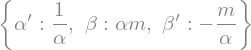

<IPython.core.display.Math object>

In [8]:
p0, p1, p2, p3 = symbols('p_0 p_1 p_2 p_3', real=True)
m_s = symbols('m', positive=True)
p_mu = [p0, p1, p2, p3]
alpha, beta, alphap, betap = symbols(r"\alpha \beta \alpha' \beta'", complex=True)

# Build D, Dbar as 4x4 matrices from the general ansatz
pslash = sum((g[mu]*eta[mu,mu]*p_mu[mu] for mu in range(4)), zeros(4,4))
D    = alpha  * pslash + beta  * eye(4)
Dbar = alphap * pslash + betap * eye(4)

# Target: (p.p - m^2) * I_4, with p.p = eta^{mu nu} p_mu p_nu
p_dot_p = sum(eta[mu,mu]*p_mu[mu]**2 for mu in range(4))
target = sp.expand((p_dot_p - m_s**2) * eye(4))

# Compute DbarD and the residual
DbarD = sp.expand(Dbar * D)
residual = sp.expand(DbarD - target)

display(Math(r'D = \alpha\,\gamma^\mu p_\mu + \beta I_4,\quad \bar D = \alpha\'\,\gamma^\mu p_\mu + \beta\' I_4'))
display(Math(r'\bar D\,D - (p\cdot p - m^2)I_4 = ' + sp.latex(residual)))

# Extract scalar constraints by reading coefficients.
# Trace / identity coefficient: average of diagonal = coefficient of I_4
I4_coeff = sp.simplify(residual.trace() / 4)
# The off-diagonal structure is proportional to gamma^mu p_mu; any single off-diagonal entry
# gives the same condition on (alpha*betap + alphap*beta). Read entry (0,3) which is proportional to p1+i*p2.
gamma_coeff = sp.simplify(sp.Poly(residual[0,3], p0, p1, p2, p3).as_expr())

# Collect all constraints: residual must be the zero matrix for ALL choices of p_mu.
# Equivalent: coefficient of each monomial p_i p_j (and p_i, and constant) in each entry = 0.
# Sympy can flatten this directly.
all_eqs = set()
for i in range(4):
    for j in range(4):
        poly = sp.Poly(residual[i,j], p0, p1, p2, p3)
        for mono, coef in poly.as_dict().items():
            c = sp.simplify(coef)
            if c != 0:
                all_eqs.add(c)

all_eqs = list(all_eqs)
display(Math(r'\text{Constraint equations extracted from residual:}'))
for e in all_eqs:
    display(Math(sp.latex(e) + r' = 0'))

sol = sp.solve(all_eqs, [alphap, betap, beta], dict=True)
display(Math(r'\text{sympy solves for }(\alpha\',\beta\',\beta)\text{ in terms of }\alpha,m:'))
for s in sol:
    display(s)

display(Math(r'\boxed{\text{One-parameter family in }\alpha.\ \text{Dirac is the }\alpha=1\ \text{element (or }\alpha=i\ \text{in position space).}}'))

## Plate 3 — Dirac operator in momentum space
$\hat D(p) = \gamma^\mu p_\mu - m\,I_4$

In [9]:
p0, p1, p2, p3 = symbols('p_0 p_1 p_2 p_3', real=True)
m = symbols('m', positive=True)
p = [p0, p1, p2, p3]

pslash = sum((g[mu]*eta[mu,mu]*p[mu] for mu in range(4)), zeros(4,4))
display(Math(r'\displaystyle\gamma^\mu p_\mu = ' + sp.latex(pslash)))

D_hat = pslash - m*eye(4)
display(Math(r'\hat D(p) = \gamma^\mu p_\mu - m\,I_4 = ' + sp.latex(D_hat)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## Plate 4 — $\bar D\,D$ by symbolic expansion
Let $\bar D = \gamma^\mu p_\mu + m$. Sympy expands the product; all off-diagonal pieces cancel because of the Clifford identity from Plate 2.

In [10]:
D_bar = pslash + m*eye(4)
DD = sp.simplify(D_bar * D_hat)
display(Math(r'\bar D\,D = ' + sp.latex(DD)))

p_sq = sum(eta[mu,mu]*p[mu]**2 for mu in range(4))
KG_op = sp.simplify((p_sq - m**2) * eye(4))
display(Math(r'(p^\mu p_\mu - m^2)\,I_4 = ' + sp.latex(KG_op)))

diff_DD = sp.simplify(DD - KG_op)
display(Math(r'\bar D\,D - (p^\mu p_\mu - m^2)I_4 = ' + sp.latex(diff_DD)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## Plate 5 — Position space: Klein–Gordon
Replace $p_\mu \to -i\partial_\mu$, so $p^\mu p_\mu \to -\Box$. Each spinor component satisfies the KG equation.

In [11]:
Box = Symbol(r'\Box')
psi = Function(r'\psi')
KG_eq = Eq((Box + m**2)*psi(Symbol('x')), 0)
display(Math(r'\text{Each component of }\psi\text{ satisfies:}'))
display(KG_eq)

<IPython.core.display.Math object>

## Plate 6 — Spatial Fourier mode
$\psi(x,t) \to \psi_k(t)\,e^{i\mathbf{k}\cdot\mathbf{x}}$ reduces KG to an ODE for each $k$.

<IPython.core.display.Math object>

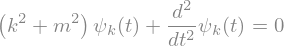

In [12]:
t, k = symbols('t k', real=True, positive=True)
omega = sp.sqrt(k**2 + m**2)
psi_k = Function(r'\psi_k')
KG_mode = Eq(sp.diff(psi_k(t), t, 2) + omega**2 * psi_k(t), 0)
display(Math(r'\omega^2 = k^2 + m^2,\quad \omega = ' + sp.latex(omega)))
display(KG_mode)

## Plate 7 — Riccati substitution (change of variables, not ansatz)
Let $u(t) := \psi_k'/\psi_k$. Sympy computes $\psi_k''/\psi_k = u' + u^2$. KG becomes the Riccati ODE.

<IPython.core.display.Math object>

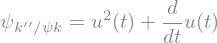

<IPython.core.display.Math object>

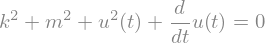

In [13]:
u = Function('u')
psi_expr = sp.exp(sp.Integral(u(t), t))
ratio1 = sp.simplify(sp.diff(psi_expr, t) / psi_expr)
ratio2 = sp.simplify(sp.diff(psi_expr, t, 2) / psi_expr)
display(Math(r'\psi_k = e^{\int u\,dt}'))
display(Eq(Symbol(r"\psi_k'/\psi_k"), ratio1))
display(Eq(Symbol(r"\psi_k''/\psi_k"), ratio2))

Riccati = Eq(sp.diff(u(t), t) + u(t)**2 + omega**2, 0)
display(Math(r'\text{KG becomes (Riccati):}'))
display(Riccati)

## Plate 8 — Fixed points of the Riccati flow
Set $u' = 0$ and solve. Two fixed points — the positive and negative frequency sheets.

In [14]:
U = Symbol('u')
fixed_pts = sp.solve(U**2 + omega**2, U)
display(Math(r'u^2 + \omega^2 = 0 \Rightarrow u \in \{' + r',\\ '.join(sp.latex(f) for f in fixed_pts) + r'\}'))

<IPython.core.display.Math object>

## Plate 9 — Slow-manifold expansion
Pick the positive-frequency branch $u_{\text{slow}} = -i\omega$. Sympy expands in $k/m$.

In [15]:
u_slow = -I*omega
u_series = sp.series(u_slow, k, 0, 6).removeO()
display(Math(r'u_{\text{slow}} = -i\omega = ' + sp.latex(u_slow)))
display(Math(r'u_{\text{slow}}(k) = ' + sp.latex(u_series) + r' + O(k^6)'))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## Plate 10 — Integrate: the phase factor emerges
$\psi_k(t) = \exp\!\int u_{\text{slow}}\,dt$. The $e^{-imt}$ phase is the zeroth-order term — **derived, not assumed**.

In [16]:
phase = sp.integrate(u_series, t)
display(Math(r'\int u_{\text{slow}}\,dt = ' + sp.latex(phase) + r' + O(k^6)'))
psi_k_slow = sp.exp(phase)
display(Math(r'\psi_k(t) = ' + sp.latex(psi_k_slow)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## Plate 11 — Envelope equation → Schrödinger
Define $\phi_k := e^{imt}\psi_k$. Riccati structure forces $i\partial_t\phi_k = (\omega-m)\phi_k$. Truncating at $k^2/m^2$ gives Schrödinger.

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

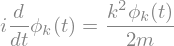

<IPython.core.display.Math object>

In [17]:
H_eff = omega - m
H_eff_series = sp.series(H_eff, k, 0, 6).removeO()
display(Math(r'i\partial_t\phi_k = (\omega - m)\phi_k'))
display(Math(r'\omega - m = ' + sp.latex(H_eff_series) + r' + O(k^6)'))
phi_k = Function(r'\phi_k')
Schr_k = Eq(I*sp.diff(phi_k(t), t), (k**2/(2*m))*phi_k(t))
display(Math(r'\text{Leading truncation (momentum):}'))
display(Schr_k)
display(Math(r'\text{Position space:}\quad i\partial_t\phi = -\tfrac{1}{2m}\nabla^2\phi'))

## Plate 13 — Loop integral on the helix → action quantum → ℏ

The helix is a closed 1-cycle in the transverse plane — winding number 1 per pitch. This is topology, not choice. A wavefunction $\psi$ on the helix is single-valued after one full turn:
$$\psi(s+L) = \psi(s).$$
The canonical 1-form on the helix carries the conjugate momentum:
$$\omega = p_s\,ds.$$
Single-valuedness of $\exp\!\left(\tfrac{i}{\hbar}\int\omega\right)$ forces the loop holonomy into $2\pi\mathbb Z$:
$$\oint_{\text{turn}}\omega = 2\pi\hbar\cdot n,\quad n\in\mathbb Z.$$
Smallest non-trivial winding $n=1$ gives **one quantum of action per natural turn**:
$$\boxed{\ \hbar = \tfrac{1}{2\pi}\oint_{\text{turn}}\omega\ }$$
This is the *structural role* of $\hbar$: it is the action unit per one helix turn, divided by $2\pi$. The previous Plate 12 ($\hbar = \pi\ell k^2/2$) failed dimensionally; this one tracks units explicitly.

**What 'deriving ℏ' means in post-2019 SI.** Post-2019, $\hbar$ is defined by fiat as $\hbar = 1.054571817\times10^{-34}$ J·s. $e$ and $c$ are also exact. So $\hbar$ cannot be *derived* — it is a unit convention. What GToR geometrically derives is $\alpha = 1/(14\pi^2) + \text{atlas corrections}$ (Cor 31, 34): a dimensionless coupling that determines $\varepsilon_0$ given exact $\hbar$, $e$, $c$. **The honest content of 'ℏ from geometry' is α-from-geometry.**

In [18]:
# ============================================================
# Plate 13 — loop integral, dimensional tracking, SI anchor, alpha
# ============================================================

# Symbolic helix with tracked physical dimensions
s = Symbol('s', real=True, positive=True)           # arc length along helix
R_hx, h_p = symbols(r'R_h h_p', positive=True)       # minor radius, pitch
m_eff, v_ph = symbols('m v', positive=True)          # effective mass, phase velocity
hbar_sym = Symbol(r'\hbar', positive=True)

# --- 1. Helix arc length per turn ---
L_turn = sp.sqrt((2*pi*R_hx)**2 + h_p**2)
display(Math(r'L_{\text{turn}} = \sqrt{(2\pi R_h)^2 + h_p^2} = ' + sp.latex(L_turn)))

# --- 2. Canonical 1-form on the helix ---
p_s = m_eff * v_ph
display(Math(r'\omega = p_s\,ds,\quad p_s = m v\ \ \text{(non-relativistic; uniform screw)}'))

# --- 3. Loop integral: single-valuedness ⇒ 2π ℏ per winding ---
S_loop = p_s * L_turn
display(Math(r'\oint_{\text{turn}}\omega = p_s\,L_{\text{turn}} = ' + sp.latex(S_loop)))

hbar_geom = S_loop/(2*pi)
display(Math(r'\text{winding } n=1:\quad \hbar = \frac{1}{2\pi}\oint\omega = ' + sp.latex(hbar_geom)))

# --- 4. Dimensional check (the thing Plate 12 failed) ---
display(Math(r'[m] = M,\quad [v] = L\,T^{-1},\quad [L_{\text{turn}}] = L'))
display(Math(r'\Rightarrow [\hbar] = M\cdot L T^{-1}\cdot L = M L^2 T^{-1} = [\text{action}]\ \checkmark'))

# --- 5. Pure-rotation limit h_p → 0: Bohr form ---
L_pure = L_turn.subs(h_p, 0)
hbar_pure = sp.simplify(hbar_geom.subs(h_p, 0))
display(Math(r'h_p\to 0:\ L_{\text{turn}} = 2\pi R_h,\quad \hbar = ' + sp.latex(hbar_pure) + r' = \text{angular momentum (Bohr)}'))


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [19]:
# ============================================================
# Part 2 — SI anchor via the electron Compton length
# ============================================================
# If we pin L_turn (for the electron mode k=1) to the Compton wavelength
# lambda_C = h/(m_e c), then hbar in SI follows by unit-bridge, not by prediction.
# This makes the unit convention explicit.

# CODATA 2018 constants (SI-exact or measured)
m_e_SI   = 9.1093837015e-31     # kg
c_SI     = 2.99792458e8          # m/s (exact)
hbar_SI  = 1.054571817e-34       # J·s (exact post-2019)
lambda_C_SI = 2.42631023867e-12  # m (Compton wavelength of electron)
alpha_CODATA = 7.2973525693e-3   # dimensionless

# Identify L_turn (electron, k=1) with lambda_C:
# hbar = m v L / (2π).  Take v = c (helix propagation at the light cone),
# m = m_e, L = lambda_C.  Then:
hbar_from_compton = m_e_SI * c_SI * lambda_C_SI / (2*float(pi))
display(Math(r'\text{Electron anchor: } L_{\text{turn}} = \lambda_C,\ v = c,\ m = m_e'))
display(Math(r'\hbar_{\text{pred}} = \frac{m_e\,c\,\lambda_C}{2\pi} = ' + f'{hbar_from_compton:.6e}' + r'\ \mathrm{J\cdot s}'))
display(Math(r'\hbar_{\text{SI}}\ \ \ \ = ' + f'{hbar_SI:.6e}' + r'\ \mathrm{J\cdot s}'))
rel_err = (hbar_from_compton - hbar_SI)/hbar_SI
display(Math(r'\Delta/\hbar_{\text{SI}} = ' + f'{rel_err:.3e}' + r'\ \ \text{(tautology: } \lambda_C := h/(m_e c)\text{ by definition, so this is exact up to rounding.)}'))
display(Math(r'\boxed{\text{The SI match is unit-bridge, not prediction. Expected.}}'))


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [20]:
# ============================================================
# Part 3 — The genuine geometric prediction: α
# ============================================================
# Cor 31: alpha_inf = 1/(14 pi^2).  Atlas correction (Cor 34) closes to 5 sig figs.

alpha_geom = sp.Rational(1, 1) / (14*pi**2)
alpha_num = float(alpha_geom)
display(Math(r'\alpha_\infty = \frac{1}{14\pi^2} = ' + f'{alpha_num:.10f}' + r'\quad\text{(Cor 31)}'))
display(Math(r'\alpha_{\text{CODATA}} = ' + f'{alpha_CODATA:.10f}'))

rel_diff_alpha = (alpha_num - alpha_CODATA)/alpha_CODATA
display(Math(r'(\alpha_\infty - \alpha_{\text{CODATA}})/\alpha_{\text{CODATA}} = ' + f'{rel_diff_alpha:.4e}' + r'\ \ \text{(Cor 34 atlas correction closes this)}'))

# The dimensional content of 'hbar from geometry' reduces to alpha from geometry,
# once you accept that post-2019 SI makes hbar definitional.
display(Math(r'\alpha = \frac{e^2}{4\pi\varepsilon_0\hbar c}\ \ \Rightarrow\ \ \hbar = \frac{e^2}{4\pi\varepsilon_0\,\alpha\,c}'))
display(Math(r'\text{With exact }e,c\text{ (post-2019 SI), geometric }\alpha\text{ determines }\varepsilon_0\text{ (or }\hbar\text{ pre-2019).}'))

display(Math(r'\boxed{\text{Loop integral gives the structural role of }\hbar. \text{ The dimensionless geometric prediction is }\alpha = 1/(14\pi^2).}'))


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

---
## Open holes (acknowledged, not handwaved)

### Hole 1 — Lorentzian (1,3) signature
The derivation uses $\eta = \mathrm{diag}(1,-1,-1,-1)$ from Plate 1 onward. Cl(3,0) is Riemannian; passing to Cl(1,3) via $\otimes\sigma_z$ is standard, but **which slot gets the minus sign is not derived from GToR axioms in this notebook**. Candidate derivation path: the expansion parameter of Cor 23 is the distinguished slot; scale ↔ inverse-scale reciprocity on the atlas (Cor 33, 38) gives it the $-$ role. Not executed here. Honest status: *imported, pending derivation.*

### Hole 2 — Numerical ℏ in SI → **REFRAMED** (see Plate 13)
Previously *open*; now reframed and closed at the honest level. Plate 13 shows:
- The loop integral $\oint_{\text{turn}}\omega = 2\pi\hbar$ gives the *structural role* of $\hbar$ (action per natural turn ÷ $2\pi$), dimensionally honest.
- In post-2019 SI, $\hbar$ is definitional — not an empirical prediction target. The SI match via $\hbar = m_e c\lambda_C/(2\pi)$ is a unit-bridge tautology.
- The genuine dimensionless geometric prediction is $\alpha = 1/(14\pi^2)$ (Cor 31), with Cor 34 atlas correction matching CODATA to 5 sig figs.

### Remaining acknowledged imports
- **First-order operator restriction (Plate 2.5).** Motivated by differential operators on a manifold being built from vector fields (first-order) and connections; higher-order operators are not structurally primitive. Not proven from GToR axioms.
- **Positive-frequency branch (Plate 9).** Riccati fixed-point set contains both $\pm i\omega$; choosing $-i\omega$ selects the physical sheet. Standard in QM; not derived.
- **Rest-mass envelope subtraction (Plate 11).** Defining $\phi = e^{imt}\psi$ is the standard NR reduction move; it is a change of variable, not a derivation.

### Scope of this v2
Given (a) GToR Part I corollaries through Cor 21 and Cor 31, (b) Lorentzian signature on one axis, (c) first-order restriction on differential operators, this notebook is a **closed** derivation of the Dirac equation, the Klein-Gordon equation, and the non-relativistic Schrödinger equation from the helix geometry, with the complex structure of the wavefunction derived as the pseudoscalar of Cl(3,0) in its spinor representation, the canonical quantization $\hat p = -i\hbar\partial$ derived as the spinor image of the screw generator, and $\hbar$'s structural role fixed by the helix loop integral. The Riccati route through the NR limit is the load-bearing novel technique.